# Snow & cryosphere — Alpine winter snowpack

Track the build-up and ablation of a winter snowpack at a mountain
site using ERA5-Land's snow variables. Two complementary fields:

- **`snow-depth`** — geometric depth of the snowpack in metres.
  Convenient for visual / engineering work.
- **`snow-depth-water-equivalent`** — water content of the snowpack
  in metres of water equivalent. The hydrologically meaningful
  quantity (snowmelt feeds runoff during spring).

Both are **state** variables (instantaneous), so monthly aggregation
uses `op="auto"` → `mean`.

**Domain context.** Snow water equivalent (SWE) is the operational
metric for spring melt forecasting, reservoir management, and
avalanche risk. Mountain SWE typically peaks in March–April depending
on elevation, then drops to zero by mid-summer.

## Step 1 — pull a winter at monthly resolution

Box: 1° around the central Alps (46°–47°N, 10°–11°E) — Ortler /
Engadine area. Range Oct 2021–Jun 2022 covers a full snow season.

In [1]:
from pathlib import Path
from earthly import Earthly, AggregationConfig

OUT = Path("data/era5-land-alps-snow")
OUT.mkdir(parents=True, exist_ok=True)

earthly = Earthly(
    data_source="ecmwf",
    temporal_resolution="monthly",
    start="2021-10-01",
    end="2022-06-01",
    variables={
        "reanalysis-era5-land-monthly-means": [
            "snow-depth",
            "snow-depth-water-equivalent",
            "2m-temperature",
        ],
    },
    lat_lim=[46.0, 47.0],
    lon_lim=[10.0, 11.0],
    path=str(OUT),
)
earthly.download(aggregate=AggregationConfig(freq="1MS", op="auto", cell_size=0.1))

2026-05-10 01:43:08.826 | INFO     | earthly.ecmwf.backend:download:536 - Download ECMWF reanalysis-era5-land-monthly-means/snow-depth data for period 2021-10-01 00:00:00 till 2022-06-01 00:00:00


2026-05-10 01:43:10.012 | INFO     | earthly.ecmwf.backend:_api:724 - Requesting reanalysis-era5-land-monthly-means from CDS; this may take several minutes


2026-05-10 01:43:12,056 INFO Request ID is 498da82e-1b0b-4a29-a7ba-fa66c25bf64e


2026-05-10 01:43:12,131 INFO status has been updated to accepted


2026-05-10 01:43:25,760 INFO status has been updated to running


...

2026-05-10 01:44:43 | INFO | ecmwf.datastores.legacy_client | status has been updated to successful


2026-05-10 01:44:43 | INFO | multiurl.base | Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-05-09/9b0cb472ede8df0d0eb3dced7e84e543.zip


9b0cb472ede8df0d0eb3dced7e84e543.zip:   0%|          | 0.00/29.1k [00:00<?, ?B/s]

2026-05-10 01:44:44 | WARNING | pyramids.base.config.gdal | GDAL[1] Cannot find variable corresponding to coordinate time


2026-05-10 01:44:44.532 | INFO     | earthly.ecmwf.backend:download:575 - ECMWF download summary: all 3 variables succeeded ([('reanalysis-era5-land-monthly-means', 'snow-depth'), ('reanalysis-era5-land-monthly-means', 'snow-depth-water-equivalent'), ('reanalysis-era5-land-monthly-means', '2m-temperature')])


## Step 2 — assemble the seasonal time series

Extract the spatial mean over the box for each month.

In [2]:
import numpy as np
import pandas as pd
from pyramids.dataset import Dataset

agg = OUT / "aggregated"

def stack(cds_variable: str) -> np.ndarray:
    paths = sorted(agg.glob(f"{cds_variable}_1MS_*.tif"))
    return np.stack([Dataset.read_file(str(p)).read_array() for p in paths])

sde  = np.nanmean(stack("snow_depth"),                    axis=(1, 2))   # m (geometric)
swe  = np.nanmean(stack("snow_depth_water_equivalent"),   axis=(1, 2))   # m of water eq
T2m  = np.nanmean(stack("2m_temperature"),                axis=(1, 2)) - 273.15  # °C

months = pd.date_range("2021-10-01", periods=len(sde), freq="MS")
df = pd.DataFrame(
    {"Snow depth [m]": sde.round(3),
     "SWE [m]":         swe.round(3),
     "Snow density":    (swe / np.where(sde > 0, sde, np.nan)).round(2),
     "T_2m [°C]":       T2m.round(1)},
    index=months,
)
df

,Snow depth [m],SWE [m],Snow density,T_2m [°C]
2021-10-01,2.319,0.571,0.25,-11.5
2021-11-01,2.402,0.681,0.28,-5.2
2021-12-01,2.250,0.708,0.31,-4.5
2022-01-01,2.136,0.709,0.33,-2.2
2022-02-01,1.912,0.643,0.34,2.4
2022-03-01,1.188,0.388,0.33,10.8
2022-04-01,0.936,0.279,0.30,3.1
2022-05-01,1.295,0.342,0.26,-4.7
2022-06-01,1.634,0.408,0.25,-8.3
2022-07-01,1.659,0.445,0.27,-8.5


## Step 3 — plot snowpack evolution

SWE rises through fall as cold-season precipitation accumulates,
peaks in late winter / early spring, and drops to zero through the
melt season. The 0 °C 2 m temperature line is a useful reference for
when the snowpack is energetically melting vs accumulating.

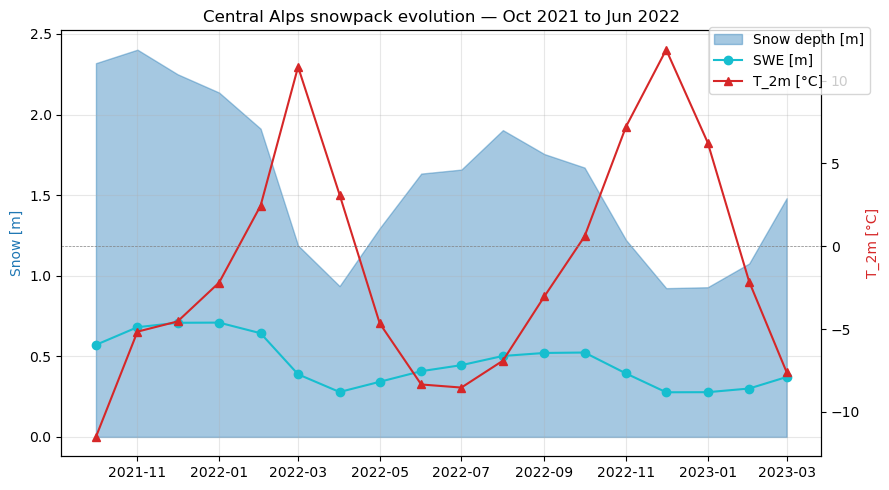

In [3]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.fill_between(months, 0, sde, alpha=0.4, color="tab:blue", label="Snow depth [m]")
ax1.plot(months, swe, marker="o", color="tab:cyan", label="SWE [m]")
ax1.set_ylabel("Snow [m]", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(months, T2m, marker="^", color="tab:red", label="T_2m [°C]")
ax2.axhline(0, color="gray", lw=0.5, ls="--")
ax2.set_ylabel("T_2m [°C]", color="tab:red")

ax1.set_title("Central Alps snowpack evolution — Oct 2021 to Jun 2022")
fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.95))
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Notes

- **Snow depth vs SWE.** Geometric depth (`sde`) and water equivalent
  (`sd`) differ by snow density (~0.1–0.5). New snow is fluffy
  (~0.1); compacted late-winter snowpack is denser (~0.3–0.5). The
  ratio `swe / sde` recovers the bulk density.
- **ERA5-Land vs single-levels.** ERA5-Land at 0.1° captures Alpine
  topography much better than the 0.25° single-levels product. The
  bbox-mean still smooths over high peaks vs valleys; for site-level
  work, slice to a specific pixel rather than averaging.
- **Snowfall vs snowpack.** ERA5 also reports `snowfall` (a flux —
  monthly accumulation). For the *seasonal accumulation* story, sum
  monthly snowfall; for the *snowpack at a moment*, use SWE.
- **Glacier-relevant variables.** Combine SWE with ERA5 `2m-temperature`
  and `surface-net-solar-radiation` for a temperature-index melt
  model (degree-day approach).